# Atividade: CNNs para Classificação

Neste notebook, iremos preparar nosso próprio dataset e treinar um modelo de classificação de imagens.

## Preparando os dados

Os dados desta atividade serão baixados da internet. Utilizaremos para isso buscadores comuns. Em seguida, dividiremos em treinamento e validação.

In [1]:
import os
import shutil
import random
!pip install icrawler
from icrawler.builtin import GoogleImageCrawler, BingImageCrawler

### Adquirindo as Imagens

Utilizaremos o iCrawler para baixar imagens em buscadores através de termos especificados. Defina sua lista de classes.

Observação: alterei de "GoogleImageCrawler" para o "BingImageCrawler", pois usando o iCrawler não foi possível ler as imagens da página do google, o erro que dava era "TypeError: 'NoneType' object is not iterable". Quando mudei para o Bing deu certo.

In [2]:
def download_images(keyword, folder, n_total=100):
    os.makedirs(folder, exist_ok=True)
    downloaded = len(os.listdir(folder))
    remaining = n_total - downloaded

    while downloaded < n_total:
        crawler = BingImageCrawler(storage={'root_dir': folder})
        crawler.crawl(keyword=keyword, max_num=remaining, file_idx_offset=downloaded)
        downloaded = len(os.listdir(folder))
        remaining = n_total - downloaded
        print(f"Downloaded {downloaded}/{n_total}")

    print("Download complete!")

In [3]:
search_terms = {
    "ferrari": "ferrari red car",
    "fusca": "fusca volkswagen beetle"
}

for label, term in search_terms.items():
    download_images(term, f"data/carros/{label}", n_total=100)

Downloaded 30/100
Downloaded 61/100
Downloaded 92/100
Downloaded 100/100
Download complete!


ERROR:downloader:Response status code 403, file https://www.pcarmarket.com/static/media/uploads/galleries/photos/uploads/galleries/31005-amaral-1972-volkswagen-fusca/.thumbnails/04.jpg
ERROR:downloader:Response status code 403, file https://images-wixmp-ed30a86b8c4ca887773594c2.wixmp.com/f/520b1cc1-ab79-4514-9d8d-d88a662f9c71/d9saanu-d3553973-2dda-4fa9-b9c6-486030bbcfaa.jpg
ERROR:downloader:Response status code 404, file https://i1.wp.com/thegarage.com.br/wp-content/uploads/2020/09/volkswagen-beetle-for-sale.jpg


Downloaded 98/100
Downloaded 100/100
Download complete!


## Verificação das imagens baixadas

Antes de fazer o treinamento e a validação eu quis ver algumas imagens que foram baixadas com os termos que coloquei.

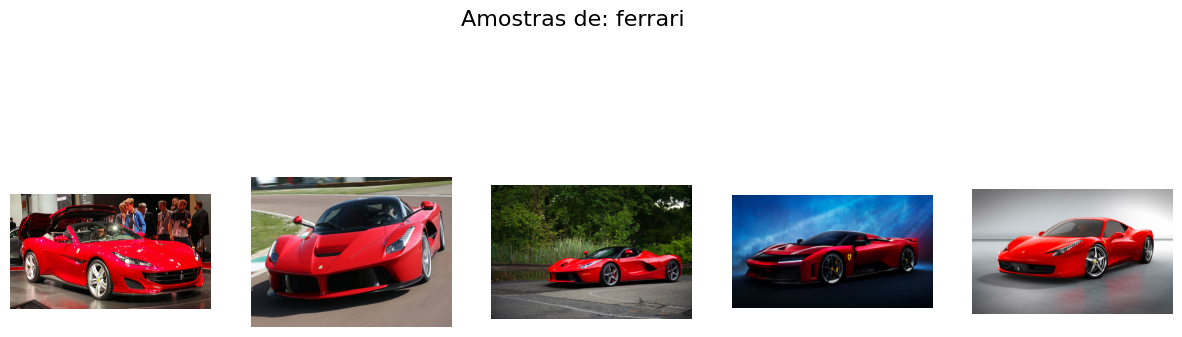

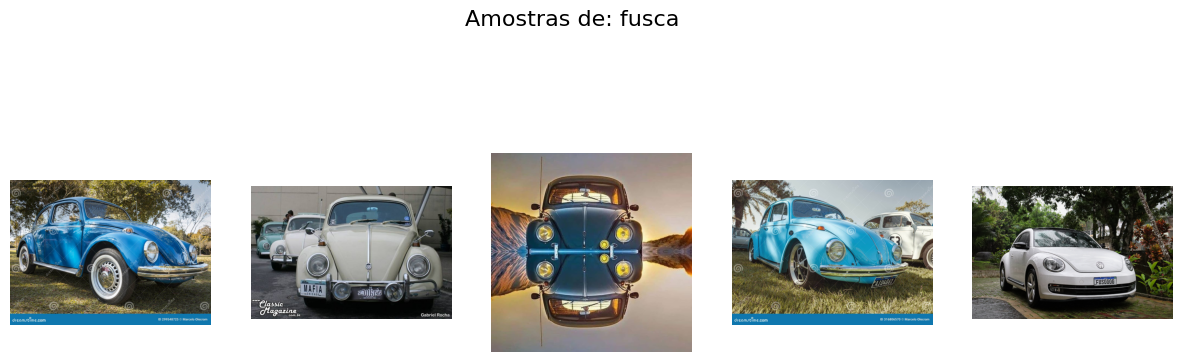

In [4]:
import matplotlib.pyplot as plt
from PIL import Image
import glob
import random
import os

def visualizar_amostras(root_dir, n_amostras=5):
    # Pega as pastas que estão dentro do diretório (ferrari, fusca)
    classes = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]

    for class_name in classes:
        class_dir = os.path.join(root_dir, class_name)
        # Pega todos os arquivos da pasta
        arquivos = glob.glob(os.path.join(class_dir, "*"))

        # Seleciona 5 imagens aleatórias para mostrar
        amostras = random.sample(arquivos, min(len(arquivos), n_amostras))

        plt.figure(figsize=(15, 5))
        plt.suptitle(f"Amostras de: {class_name}", fontsize=16)

        for i, img_path in enumerate(amostras):
            try:
                img = Image.open(img_path)
                plt.subplot(1, n_amostras, i+1)
                plt.imshow(img)
                plt.axis('off')
            except:
                print(f"Erro ao abrir {img_path}")
        plt.show()

# Chama a função apontando para a pasta onde eu salvei (data/carros)
visualizar_amostras("data/carros")

### Treinamento e Validação

Dividiremos as imagens baixadas nas pastas `train` e `val`. Defina uma porcentagem.

In [7]:
def split_train_val(root_dir, train_ratio=0.8, seed=42):
    random.seed(seed)

    train_dir = root_dir + "_split/train"
    val_dir = root_dir + "_split/val"

    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(val_dir, exist_ok=True)

    for class_name in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        images = [os.path.join(class_path, f) for f in os.listdir(class_path)]
        images = [f for f in images if os.path.isfile(f)]
        random.shuffle(images)

        n_train = int(len(images) * train_ratio)

        train_class_dir = os.path.join(train_dir, class_name)
        val_class_dir = os.path.join(val_dir, class_name)
        os.makedirs(train_class_dir, exist_ok=True)
        os.makedirs(val_class_dir, exist_ok=True)

        for img in images[:n_train]:
            shutil.copy(img, os.path.join(train_class_dir, os.path.basename(img)))
        for img in images[n_train:]:
            shutil.copy(img, os.path.join(val_class_dir, os.path.basename(img)))

        print(f"{class_name}: {n_train} train, {len(images)-n_train} val")

## Dataset

Implemente um Dataset PyTorch que carregue as imagens baixadas com suas respectivas classes. Aplique data augmentation e carregue em batches.

In [8]:
split_train_val("data/carros")

ferrari: 80 train, 20 val
fusca: 80 train, 20 val


In [9]:
# Célula: Dataset
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Configurações
BATCH_SIZE = 32
IMG_SIZE = 224 # Tamanho padrão para modelos como ResNet

DATA_DIR = "data/carros" # Apontando para onde eu baixei as imagens da Ferrari e do Fusca

# Transformações (Data Augmentation para Treino e Normalização para Validação)
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# O script de split criou pastas com sufixo "_split", então ajustei aqui:
train_dir = DATA_DIR + "_split/train"
val_dir = DATA_DIR + "_split/val"

try:
    image_datasets = {
        'train': datasets.ImageFolder(train_dir, data_transforms['train']),
        'val': datasets.ImageFolder(val_dir, data_transforms['val'])
    }

    dataloaders = {
        'train': DataLoader(image_datasets['train'], batch_size=BATCH_SIZE, shuffle=True),
        'val': DataLoader(image_datasets['val'], batch_size=BATCH_SIZE, shuffle=False)
    }

    dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
    class_names = image_datasets['train'].classes
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    print(f"Classes encontradas: {class_names}") # Deve imprimir ['ferrari', 'fusca']
    print(f"Dispositivo de treinamento: {device}")

except FileNotFoundError:
    print(f"ERRO: Não encontrei as pastas em {train_dir}. Verifique se rodou o 'split_train_val' corretamente.")

Classes encontradas: ['ferrari', 'fusca']
Dispositivo de treinamento: cuda:0


## Definição do Modelo

Defina aqui o modelo que será utilizado, sendo implementação própria ou um modelo pré-treinado. Teste diversas arquiteturas diferentes e verifique qual delas tem melhor desempenho em validação.

In [27]:
# Célula: Definição do Modelo (Testando Arquiteturas Diferentes)
import torch.nn as nn
from torchvision import models

def get_model(model_name, num_classes):
    print(f"Carregando modelo: {model_name}...")

    if model_name == 'resnet18':
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        # Congelar pesos
        for param in model.parameters():
            param.requires_grad = False
        # ResNet usa ".fc" na última camada
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, num_classes)

    elif model_name == 'mobilenet_v2':
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        for param in model.parameters():
            param.requires_grad = False
        # MobileNet usa ".classifier" e é uma lista, precisei mudar o último item (índice 1)
        num_ftrs = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(num_ftrs, num_classes)

    elif model_name == 'vgg16':
        model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        for param in model.parameters():
            param.requires_grad = False
        # VGG usa ".classifier" e o último item é o índice 6
        num_ftrs = model.classifier[6].in_features
        model.classifier[6] = nn.Linear(num_ftrs, num_classes)

    else:
        print("Modelo não implementado neste exemplo.")
        return None

    return model.to(device)

# Opções: 'resnet18', 'mobilenet_v2', 'vgg16'
NOME_MODELO = 'resnet18'

# Cria o modelo
model = get_model(NOME_MODELO, len(class_names))

# Para saber qual modelo foi usado e ficar no print depois
if model is not None:
    print(f"Modelo {NOME_MODELO} carregado com sucesso!")

Carregando modelo: resnet18...
Modelo resnet18 carregado com sucesso!


## Treinamento

Defina a função de custo e o otimizador do modelo. Em seguida, implemente o código de treinamento e treine-o. Ao final, exiba as curvas de treinamento e validação para a loss e a acurácia.

Epoch 0/9
----------
train Loss: 0.6136 Acc: 0.6625
val Loss: 0.6226 Acc: 0.6000

Epoch 1/9
----------
train Loss: 0.4304 Acc: 0.8938
val Loss: 0.4820 Acc: 0.8250

Epoch 2/9
----------
train Loss: 0.3189 Acc: 0.9563
val Loss: 0.3999 Acc: 0.8500

Epoch 3/9
----------
train Loss: 0.2442 Acc: 0.9688
val Loss: 0.3443 Acc: 0.8500

Epoch 4/9
----------
train Loss: 0.1914 Acc: 0.9938
val Loss: 0.3119 Acc: 0.9000

Epoch 5/9
----------
train Loss: 0.2230 Acc: 0.9563
val Loss: 0.2788 Acc: 0.8500

Epoch 6/9
----------
train Loss: 0.1549 Acc: 0.9813
val Loss: 0.2648 Acc: 0.9000

Epoch 7/9
----------
train Loss: 0.1248 Acc: 0.9938
val Loss: 0.2509 Acc: 0.9000

Epoch 8/9
----------
train Loss: 0.1593 Acc: 0.9750
val Loss: 0.2376 Acc: 0.9000

Epoch 9/9
----------
train Loss: 0.1516 Acc: 0.9625
val Loss: 0.2258 Acc: 0.9000

Treinamento completo em 1m 14s
Melhor Acurácia de Validação: 0.9000

RELATÓRIO FINAL: Modelo resnet18 finalizado!



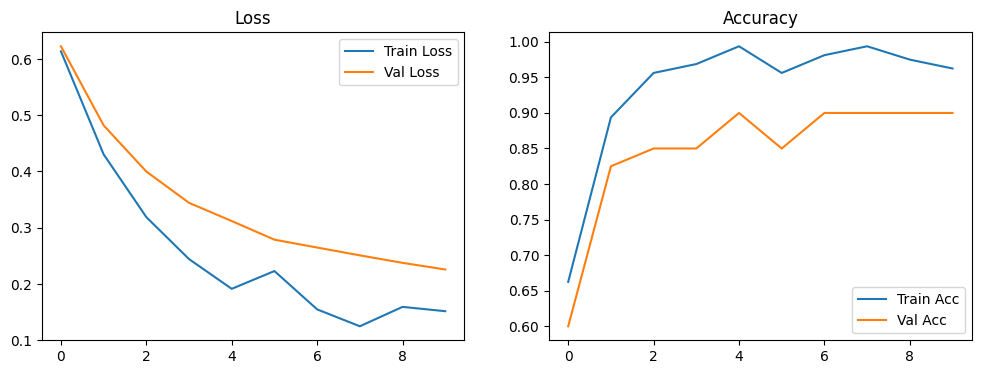

In [28]:
# Célula: Treinamento
import torch.optim as optim
import time
import copy

# Definição de Loss e Otimizador
criterion = nn.CrossEntropyLoss()

params_to_update = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.Adam(params_to_update, lr=0.001)

def train_model(model, criterion, optimizer, num_epochs=10):
    since = time.time()

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Treinamento completo em {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Melhor Acurácia de Validação: {best_acc:.4f}')

    model.load_state_dict(best_model_wts)
    return model, history

# Executar treinamento
model_ft, history = train_model(model, criterion, optimizer, num_epochs=10)

# Modelo utilizado
print("\n" + "="*40)
print(f"RELATÓRIO FINAL: Modelo {NOME_MODELO} finalizado!")
print("="*40 + "\n")

# Plotar Curvas
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.legend()
plt.title('Accuracy')
plt.show()

## Inferência

Calcule algumas métricas como acurácia, matriz de confusão, etc. Em seguida, teste o modelo em novas imagens das classes correspondentes mas de outras fontes (outro buscador, fotos próprias, etc).

              precision    recall  f1-score   support

     ferrari       1.00      0.80      0.89        20
       fusca       0.83      1.00      0.91        20

    accuracy                           0.90        40
   macro avg       0.92      0.90      0.90        40
weighted avg       0.92      0.90      0.90        40



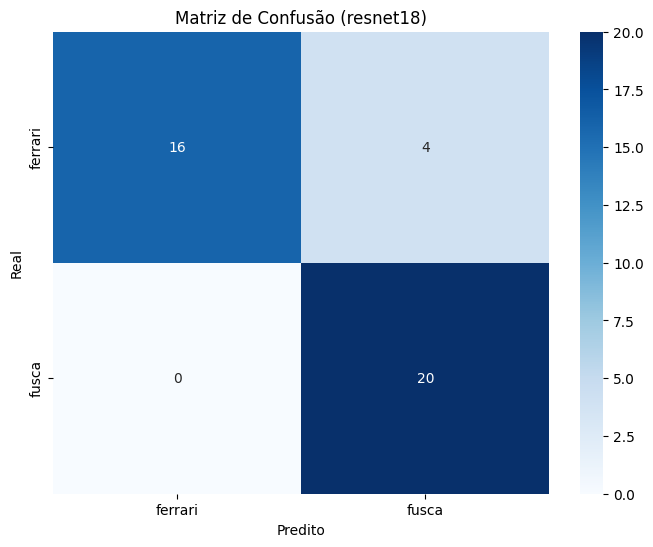

In [29]:
# Célula: Inferência
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def evaluate_model(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return all_labels, all_preds

# 1. Matriz de Confusão e Métricas
y_true, y_pred = evaluate_model(model_ft, dataloaders['val'])

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title(f'Matriz de Confusão ({NOME_MODELO})')
plt.show()


Os resultados utilizando os modelos resnet18, mobilenet_v2 e vgg16 foram esses conforme abaixo (Se a visualização estiver dificultada é só dar um zoom-in)

## Modelo Resnet18 -> Treinamento + Inferência

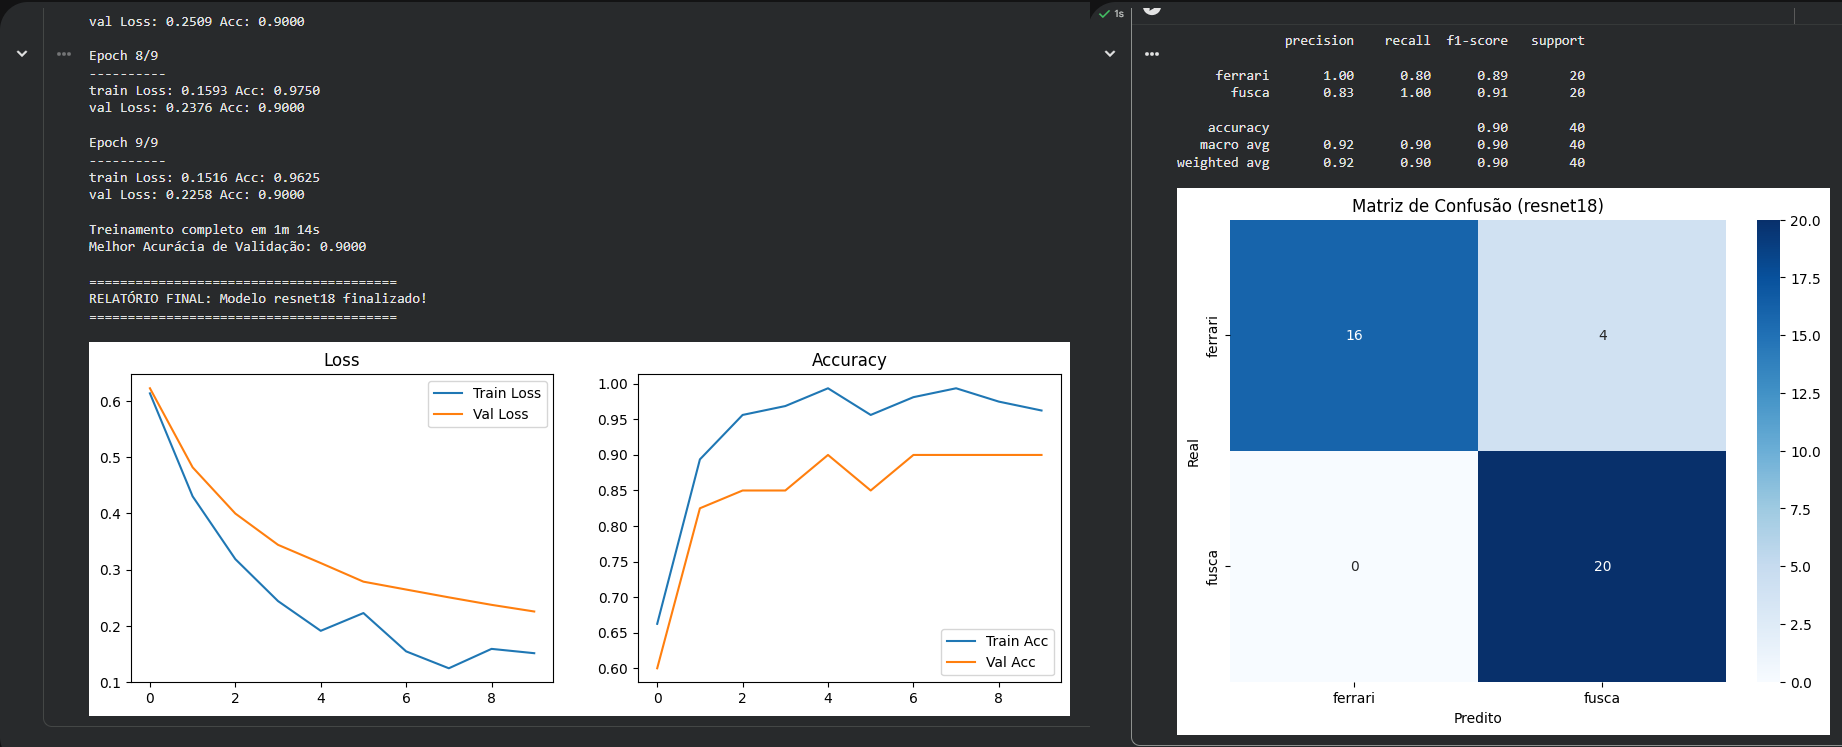

## Modelo VGG16 -> Treinamento + Inferência

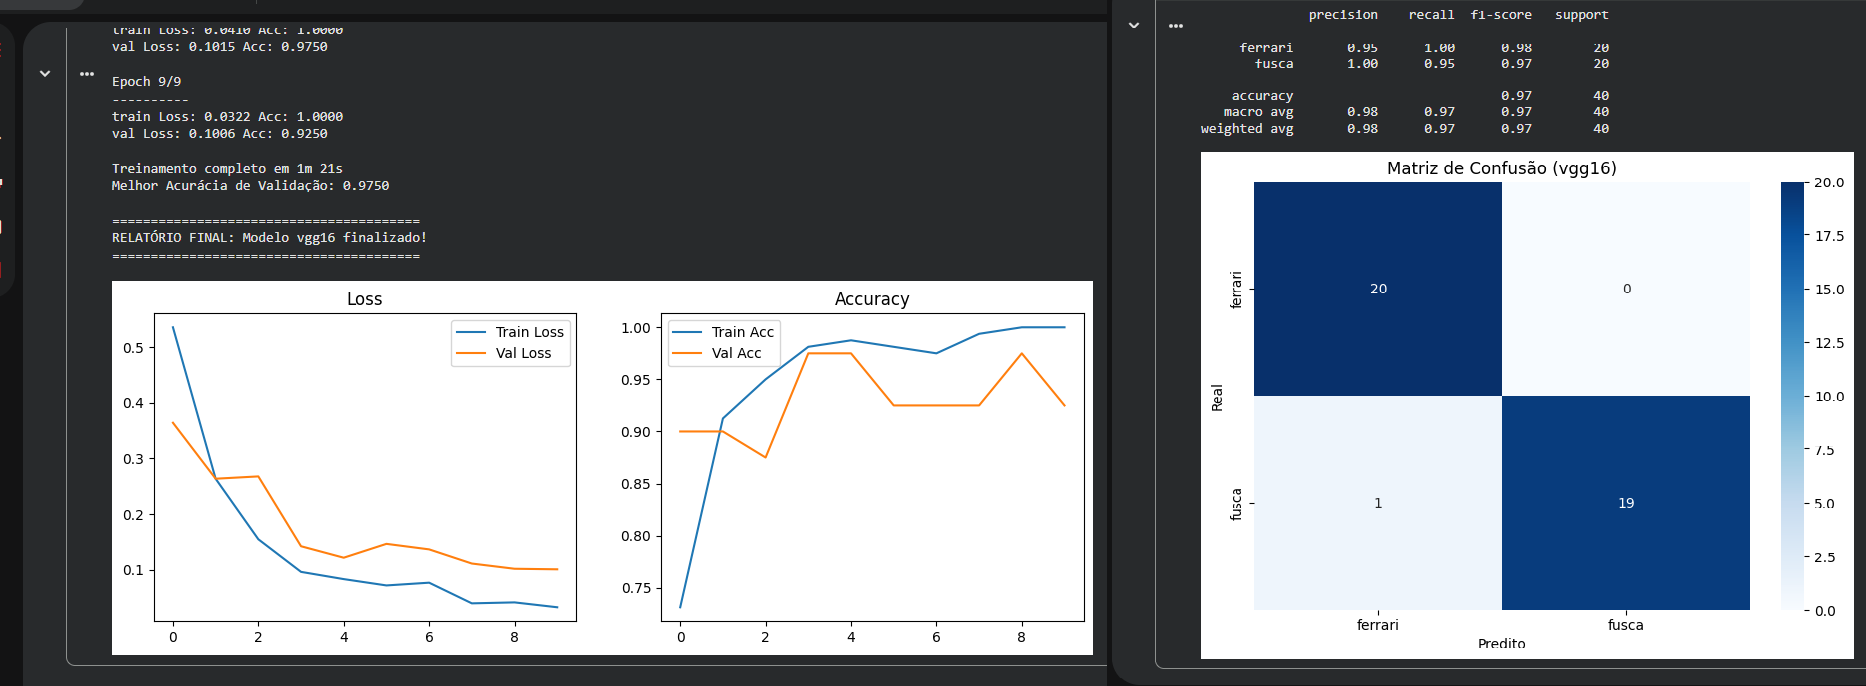

## Modelo Mobilenet_v2 -> Treinamento + Inferência

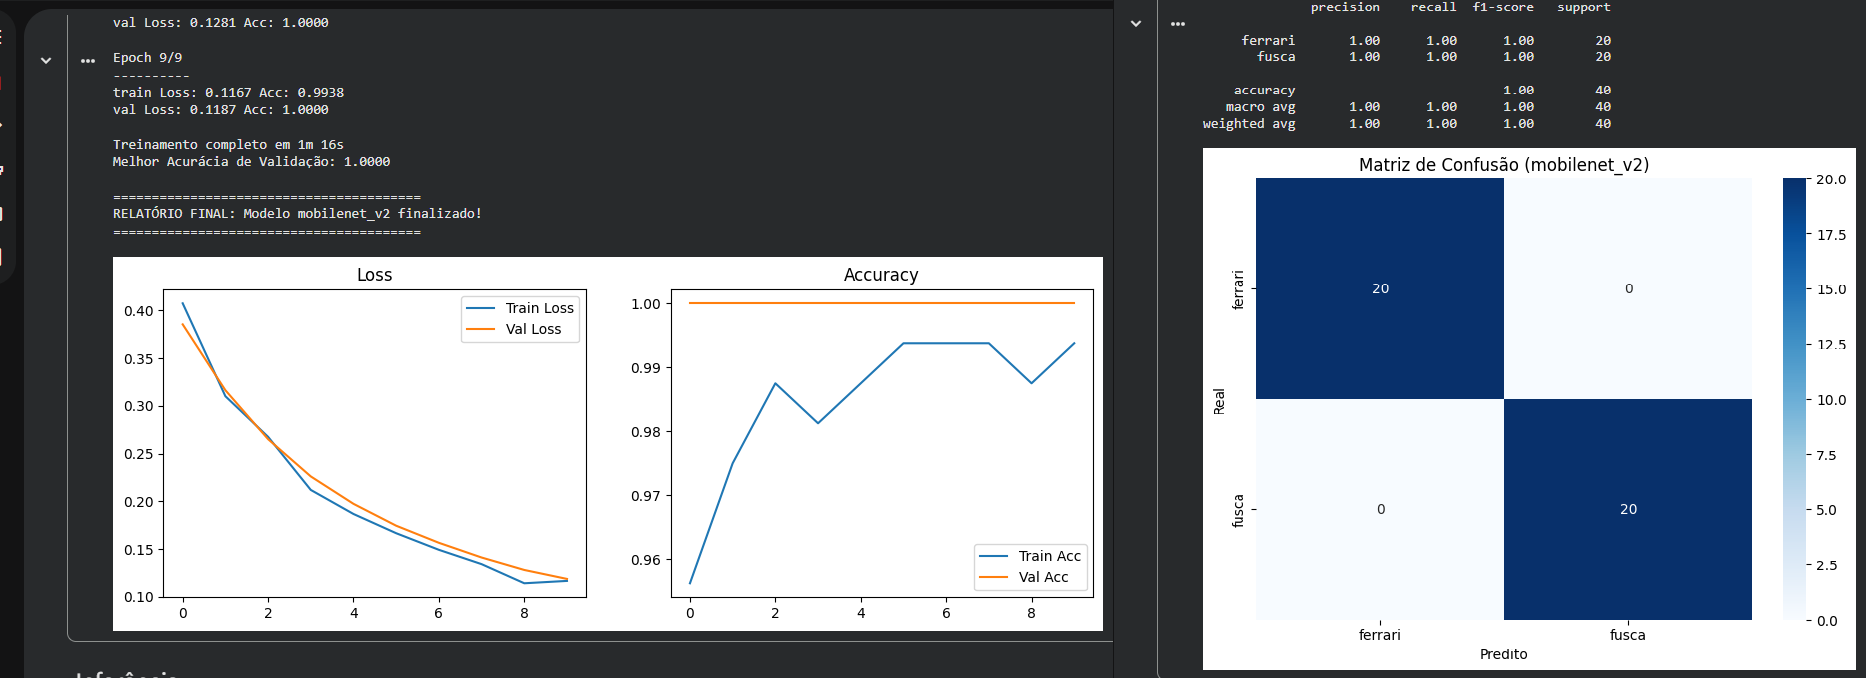

# Relatório de Experimento — Classificação de Veículos com Transfer Learning
## **1. Criação do Dataset e Preparação dos Dados**

  No começo do projeto eu precisei montar meu próprio dataset, e como gosto de carros eu pensei em Ferraris e Fuscas.

  Tive um problema logo de cara, o GoogleImageCrawler começou a dar erro (aquele TypeError dizendo que algo era NoneType etc), provavelmente porque o Google mudou alguma coisa no site e o parser não entendeu mais nada, então a saída que achei foi usar o buscador do Bing (BingImageCrawler), que funcionou sem dor de cabeça.

  As classes ficaram assim:

  Ferrari — usei o termo “ferrari red car”, coloquei o “red” pra tentar deixar tudo mais padronizado e facilitar o aprendizado, pelo menos nesse começo.

  Fusca — termo “fusca volkswagen beetle”.

  Baixei 100 imagens pra cada classe, depois o próprio código deixado pelo senhor dividiu em 80% treino e 20% validação. No fim ficaram 40 imagens só pra validação.

---


## **2. Metodologia (Transfer Learning)**

  Como o dataset era pequeno demais pra treinar um modelo do zero, usei Transfer Learning, que basicamente pega um modelo já treinado no ImageNet e troca só a última camada pra ele aprender a classificar Ferrari e Fusca.

  Testei três arquiteturas:

  ResNet18 — leve e famosa.

  MobileNet_V2 — otimizada, rápida e muito eficiente.

  VGG16 — clássica, profunda e bem pesada.

  A ideia era ver qual delas funcionaria melhor nesse caso.

---


## **3. Resultados e Comparação**

  Treinei cada modelo por 10 épocas. Os resultados ficaram assim:

    Modelo	            Tempo de Treino	        Acurácia Val.	    Erros
    MobileNet_V2	         1m 16s	                100%	          0
    VGG16	                 1m 21s	                97.5%	          1
    ResNet18	             1m 14s	                90%	              4

 - **MobileNet_V2 (A campeã)**

    Foi a que mandou melhor, acertou tudo, literalmente. As curvas de loss de treino e validação desceram “bonitinhas” juntas, sem sinais de overfitting. A impressão é que ela identificou rápido as diferenças mais marcantes entre os carros, tipo a forma arredondada do Fusca vs. as linhas mais agressivas da Ferrari.

 - **VGG16**

    Também foi muito bem, só errou uma imagem. Como ela é um modelo bem grande, demorou um pouco mais pra treinar, mesmo com poucas imagens. A validação oscilou mais que a MobileNet, normal pra uma rede tão pesada e com tão pouca informação.

 - **ResNet18**

    Surpreendentemente ficou em último, com 90%. Ela acabou confundindo 4 Ferraris com Fuscas. Olhando a curva de Loss, dá pra perceber que a validação parou de melhorar por volta da época 4, o que sugere um leve overfitting, talvez por conta de algumas Ferrari fora do padrão (ângulos estranhos, cores diferentes etc).

---


## **4. Deduções e Aprendizados**

  **Uma coisa ficou clara nesse experimento: o modelo mais leve nem sempre é pior, e o mais pesado nem sempre é melhor. A MobileNet, apesar de ser enxuta, foi a que teve o melhor desempenho. Ela se encaixa bem quando temos poucos dados e classes bem distintas.**

  **Outro ponto é que o dataset limpo ajudou muito. Especificar “red” na Ferrari deixou as imagens mais consistentes e se eu tivesse colocado Ferraris amarelas, pretas, cinzas, provavelmente a rede teria tido mais dificuldade.**
